In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#tùy biến cấu hình train

#tên model muốn train
MODEL_NAME = "yolo26n-seg.pt"

#tên dataset muốn train
DATASET_NAME = "35_special_images_segmentation.v1i.yolov8"

#tên lần train lưu lại trong thư mục content/runs/detect/Rice_seed_detection/{tên}, ưu tiên kết hợp tên dataset và model
TRAINED_RESULT_NAME = "35_special_images_segmentation.v1i.yolov8_v1_trained"

#thay đổi tùy theo tài khoản
PRIVATE_SOURCE_PATH = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/"

#folder chứa các model
MODELS_PATH = f"{PRIVATE_SOURCE_PATH}MODELS/"

#folder chứa dataset
DATAS_PATH = f"{PRIVATE_SOURCE_PATH}DATASETS/"

#folder chứa các loại hình ảnh để test thử cho các mục đích khác nhau
TEST_IMAGES_PATH = f"{PRIVATE_SOURCE_PATH}TEST_IMAGES/"

#folder chứa hình ảnh dùng để detect thử sau khi train sahi hoặc yolo
DETECTABLE_TEST_IMAGES_PATH = f"{TEST_IMAGES_PATH}DETECTABLE_TEST_IMAGES/"

#folder chứa các hình ảnh hạt lúa đã được cắt ra để thử phân lớp (classification)
CROPPED_TEST_IMAGES_PATH = f"{TEST_IMAGES_PATH}CROPPED_TEST_IMAGES/"

#folder chứa các hình ảnh gốc để test toàn bộ luồng làm việc
ORIGINAL_RANDOM_TEST_IMAGES_PATH = f"{TEST_IMAGES_PATH}ORIGINAL_RANDOM_TEST_IMAGES/"

#folder chứa kết quả sau khi train nằm trên content tạm
TRAINED_RESULTS_PATH = f"/content/runs/segment/yolo26_rice_seg/{TRAINED_RESULT_NAME}/"

#folder sẽ được chứa kết quả sau khi train nằm trong drive
TRAINED_RESULTS_DESTINATION_PATH = f"{PRIVATE_SOURCE_PATH}RESULTS/{TRAINED_RESULT_NAME}/"



#khai báo cấu trúc lưu lại các kết quả của sahi

#nơi chứa các hình ảnh được detect nhưng chưa được cắt
SAHI_DETECTION_CONTENT_PATH = f"/content/SAHI/{TRAINED_RESULT_NAME}/DETECTED_OBJECTS/"

#nơi chứa các hình ảnh được detect đẫ được cắt
CROPPED_SAHI_DETECTION_CONTENT_PATH = f"/content/SAHI/{TRAINED_RESULT_NAME}/CROPPED_DETECTED_OBJECTS/"

#nơi chứa cả 2 loại hình ảnh đã cắt và chưa cắt
SAHI_DETECTION_RESULT_CONTENT_PATH = f"/content/SAHI/{TRAINED_RESULT_NAME}/"

#nơi lưu kết quả sahi
SAHI_DETECTION_RESULT_DESTINATION_PATH = f"{PRIVATE_SOURCE_PATH}DETECTED_OBJECTS/{TRAINED_RESULT_NAME}/"

#dành cho full test

#nơi chứa các hình ảnh được detect nhưng chưa được cắt
FULL_TEST_DETECTION_CONTENT_PATH = f"/content/FULL_TEST/{TRAINED_RESULT_NAME}/DETECTED_OBJECTS/"

#nơi chứa các hình ảnh được detect đẫ được cắt
CROPPED_FULL_TEST_DETECTION_CONTENT_PATH = f"/content/FULL_TEST/{TRAINED_RESULT_NAME}/CROPPED_DETECTED_OBJECTS/"

#nơi chứa cả 2 loại hình ảnh đã cắt và chưa cắt
FULL_TEST_DETECTION_RESULT_CONTENT_PATH = f"/content/FULL_TEST/{TRAINED_RESULT_NAME}/"


In [ ]:
import cv2
import os
import math
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# xử lý ellipsoid
THICKNESS_RATIO = {
    "hat_nguyen":     0.9,
    "hat_khuyet_tat": 0.9,
    "undefined":      0.55,
}

def compute_ellipsoid_volume(local_mask_uint8, label):
    contours, _ = cv2.findContours(local_mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    ellipse_params = None

    if len(contours) == 0 or max(contours, key=cv2.contourArea).shape[0] < 5:
        h, w = local_mask_uint8.shape[:2]
        a, b = max(w, h) / 2, min(w, h) / 2
        fit_method = "BoundingRect (fallback)"
    else:
        largest       = max(contours, key=cv2.contourArea)
        ellipse_cv    = cv2.fitEllipse(largest)
        ellipse_params = ellipse_cv
        MA, ma        = ellipse_cv[1]
        a, b          = MA / 2, ma / 2
        fit_method = "fitEllipse (cv2)"

    k      = THICKNESS_RATIO.get(label, 0.55)
    c      = a * k
    volume = (4 / 3) * math.pi * a * b * c

    return {
        "vol_px3": volume,
        "a_px": a,
        "b_px": b,
        "c_px": c,
        "k_factor": k,
        "fit": fit_method,
        "ellipse_params": ellipse_params
    }

def draw_ellipse_overlay(crop_bgr, local_mask_uint8, ell_result):
    vis = cv2.cvtColor(crop_bgr.copy(), cv2.COLOR_BGR2RGB)
    contours, _ = cv2.findContours(local_mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(vis, contours, -1, (0, 220, 80), 1)

    ep = ell_result["ellipse_params"]
    if ep is not None:
        center = (int(ep[0][0]), int(ep[0][1]))
        axes   = (int(ep[1][0] / 2), int(ep[1][1] / 2))
        angle  = ep[2]
        cv2.ellipse(vis, center, axes, angle, 0, 360, (255, 80, 0), 2)

        angle_rad = math.radians(angle)
        ax_end = (int(center[0] + ell_result["a_px"] * math.cos(angle_rad)), int(center[1] + ell_result["a_px"] * math.sin(angle_rad)))
        bx_end = (int(center[0] - ell_result["b_px"] * math.sin(angle_rad)), int(center[1] + ell_result["b_px"] * math.cos(angle_rad)))
        cv2.arrowedLine(vis, center, ax_end, (220, 30, 30), 2, tipLength=0.2)
        cv2.arrowedLine(vis, center, bx_end, (30, 80, 220), 2, tipLength=0.2)

    return vis

def process_grain(img_path, label="hat_nguyen"):
    """
    Đầu vào: Đường dẫn tới 1 file ảnh PNG (có thể có nền trong suốt) và nhãn hạt lúa.
    Đầu ra : Tuple gồm (metrics, vis_img)
        - metrics (dict): Các thông số kích thước và thể tích.
        - vis_img (array): Bức ảnh đã được vẽ thêm Ellipse.
    """
    # 1. Đọc ảnh và ép OpenCV đọc cả kênh Alpha (trong suốt)
    img_bgra = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img_bgra is None:
        raise FileNotFoundError(f"Không tìm thấy ảnh tại: {img_path}")

    # 2. Xử lý triệt để lớp nền tàng hình (Xóa các hạt lúa hàng xóm)
    if len(img_bgra.shape) == 3 and img_bgra.shape[2] == 4:
        crop_bgr = img_bgra[:, :, :3].copy()    # Lấy 3 màu RGB
        alpha_channel = img_bgra[:, :, 3]       # Lấy lớp mặt nạ Alpha
        crop_bgr[alpha_channel == 0] = [0, 0, 0] # Bóp nát pixel vô hình thành Đen thui
    else:
        crop_bgr = img_bgra.copy()

    # 3. Tạo mask nhị phân từ ảnh hạt lúa đã làm sạch nền
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    _, local_mask_uint8 = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

    # 4. Tính toán bằng hàm toán học của bạn
    metrics = compute_ellipsoid_volume(local_mask_uint8, label)

    # 5. Vẽ đồ họa bằng hàm vẽ của bạn
    vis_img = draw_ellipse_overlay(crop_bgr, local_mask_uint8, metrics)

    return metrics, vis_img

{'vol_px3': 205163.61154342195, 'a_px': 25.008779525756836, 'b_px': 87.01301574707031, 'c_px': 22.507901573181154, 'k_factor': 0.9, 'fit': 'fitEllipse (cv2)', 'ellipse_params': ((69.95391845703125, 54.429141998291016), (50.01755905151367, 174.02603149414062), 133.2340545654297)}
✅ XỬ LÝ THÀNH CÔNG: test1_grain_024.png
 📦 Thể tích hạt lúa: 205,163.61 px³
 📏 Bán trục a (dài) : 25.01 px
 📏 Bán trục b (rộng): 87.01 px


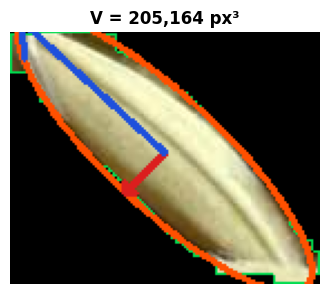

In [ ]:
# KHAI BÁO ĐƯỜNG DẪN ẢNH
img_path = "/content/test1_grain_024.png"

thong_so, anh_ket_qua = process_grain(img_path, label="hat_nguyen")

# IN RA KẾT QUẢ MÀ BẠN QUAN TÂM NHẤT (THỂ TÍCH)
print(thong_so)
print("="*40)
print(f"✅ XỬ LÝ THÀNH CÔNG: {img_path.split('/')[-1]}")
print(f" 📦 Thể tích hạt lúa: {thong_so['vol_px3']:,.2f} px³")
print(f" 📏 Bán trục a (dài) : {thong_so['a_px']:.2f} px")
print(f" 📏 Bán trục b (rộng): {thong_so['b_px']:.2f} px")
print("="*40)

# HIỂN THỊ HÌNH ẢNH TRỰC QUAN
plt.figure(figsize=(4, 4))
plt.imshow(anh_ket_qua)
plt.title(f"V = {thong_so['vol_px3']:,.0f} px³", fontweight='bold')
plt.axis('off')
plt.show()
